## Nurislam Aliyev


### Instructor: Senior-Lecturer, Aidyn Abirov

#### Homework 1, without optionals


#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Defining functions

In [2]:
def f(x):
    return np.sin(x)

def df_true(x):
    return np.cos(x)


def deriv_forward(f,x,h):
    return (f(x+h)-f(x-h))/h


def deriv_central(f,x,h):
    return (f(x+h) - f(x-h))/(2*h)

x0 = 1.0

print("true:", df_true(x0))
print("forward  h=1e-5:", deriv_forward(f, x0, 1e-5))
print("central  h=1e-5:", deriv_central(f, x0, 1e-5))

true: 0.5403023058681398
forward  h=1e-5: 1.0806046117139978
central  h=1e-5: 0.5403023058569989


###  Calculated Forward and Central difference errors 

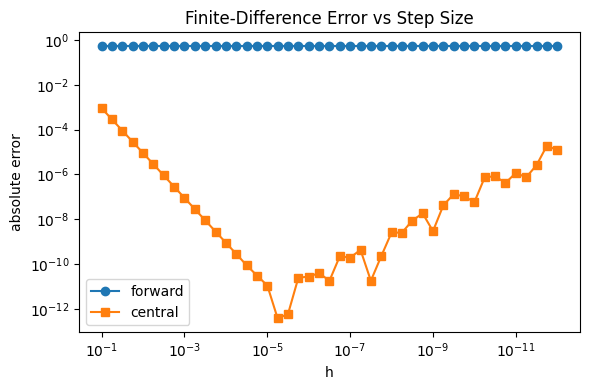

best h, forward: 0.1
best h, central: 5.623413251903491e-06


In [3]:
hs = np.logspace(-1, -12, 45)

err_fwd = np.array([
    abs(deriv_forward(f, x0, h) - df_true(x0))
    for h in hs
])

err_ctr = np.array([
    abs(deriv_central(f, x0, h) - df_true(x0))
    for h in hs
])


plt.figure(figsize=(6, 4))
plt.loglog(hs, err_fwd, "o-", label="forward")
plt.loglog(hs, err_ctr, "s-", label="central")
plt.gca().invert_xaxis()

plt.xlabel("h")
plt.ylabel("absolute error")
plt.legend()
plt.title("Finite-Difference Error vs Step Size")
plt.tight_layout()
plt.show()

print("best h, forward:", hs[np.argmin(err_fwd)])
print("best h, central:", hs[np.argmin(err_ctr)])



#### Test

In [4]:
assert abs(
    deriv_central(f, x0, 1e-5) - df_true(x0)
) < 1e-7

print("Task 1 OK")

Task 1 OK


****


**Which method gives a smaller error near its optimal h?** 
 
central limit because its more accurate that the forward method

**Why does the error eventually increase when h becomes extremely small?**

The error eventually increases when h becomes extremely small because floating-point round-off errors begin to dominate and overwhelm the decreasing truncation errors

**Why is the central-difference method generally more accurate than the forward-difference method?**

The reason is just that a Central Difference scheme is designed to remove more terms in the Taylor Series expansion compared to the Forward Difference, in turn reducing truncation error.

****

### Task 2 - Gradient of Scalar Function

In [5]:
rng = np.random.default_rng(0)


def f(w):
    return w[0]**2 + 3*w[0]*w[1] + 2*w[1]**2


def grad_analytic(w):
    df_dw0 = 2*w[0] + 3*w[1]
    df_dw1 = 3*w[0] + 4*w[1] 
    return np.array([df_dw0, df_dw1])


def numeric_gradient(f, w, h=1e-5):

    g = np.zeros_like(w, dtype=float)

    for i in range(len(w)):

        w_plus = w.copy()
        w_minus = w.copy()
        
        w_plus[i] += h
        w_minus[i] -= h
        g[i] = (f(w_plus) - f(w_minus)) / (2*h)
        
    return g


w = np.array([1.0, 2.0])

ga = grad_analytic(w)
gn = numeric_gradient(f, w)

print("f(w)          =", f(w))
print("analytic grad =", ga)
print("numeric grad  =", gn)

print(
    "max abs diff =",
    np.max(np.abs(ga - gn))
)


eps = 1e-3

d_grad = ga / np.linalg.norm(ga)

gain_grad = f(w + eps * d_grad) - f(w)

gains_random = []

for _ in range(20):

    d = rng.normal(size=2)
    d /= np.linalg.norm(d)

    gains_random.append(
        f(w + eps * d) - f(w)
    )

print("gain along gradient :", gain_grad)
print("best random gain    :", max(gains_random))


assert np.allclose(ga, [8.0, 11.0])
assert np.max(np.abs(ga - gn)) < 1e-6

assert gain_grad >= max(gains_random) - 1e-9

print("Task 2 OK")


f(w)          = 15.0
analytic grad = [ 8. 11.]
numeric grad  = [ 8. 11.]
max abs diff = 1.1647038888895622e-10
gain along gradient : 0.013604551589814662
best random gain    : 0.013554948328849292
Task 2 OK


****

**What is the difference between a derivative and a gradient?**

Derivative: Rate of change of a scalar function with respect to a single scalar variable. Typically written f′(x) or df/dx. Applicable to functions f: R → R.
Gradient: Vector of partial derivatives of a scalar function with respect to several variables. Written ∇f or ∇f(x) = (∂f/∂x1, ∂f/∂x2, …). Applicable to functions f: R^n → R.

**Why do we use .copy() when creating w_plus and w_minus?**

Because the numpy arrays are mutable and if we didnt use .copy() then we would assign and w.plus and w.minus to the same variable, and also we would just change the variable w itself..copy() gives you an independent array so you can safely perturb.

**Why must we perturb one coordinate at a time when calculating the gradient?**

Because a partial derivative is defined as the rate of change holding all other variables fixed. If you moved multiple coordinates simultaneously, the resulting change in f would be a mix of several partials' effects (plus cross terms), and you couldn't isolate how much came from coordinate i alone. One-at-a-time perturbation is what makes the finite-difference formula correspond to a genuine partial derivative

**What does it mean that the gradient points in the direction of steepest ascent?**
The gradient vector points in the direction where a function increases most rapidly



****

### Task 3 — The Chain Rule: By Hand and in Code

In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def forward(w, b, x, y):

    z = w*x + b       
    a = sigmoid(z)       
    L = (a-y)**2       

    return z, a, L


def grad_analytic(w, b, x, y):

    z, a, L = forward(w, b, x, y)

    dL_da = 2 * (a-y) 
    da_dz = a * (1-a)
    dz_dw = x 
    dz_db = 1

    dL_dw = dL_da * da_dz * dz_dw
    dL_db = dL_da * da_dz * dz_db

    return dL_dw, dL_db


def numeric_gradient_wb(w, b, x, y, h=1e-5):
    ndw = (forward(w + h, b, x, y)[2] - forward(w - h, b, x, y)[2]) / (2 * h)
    ndb = (forward(w, b + h, x, y)[2] - forward( w, b - h, x, y )[2]) / (2 * h)

    return ndw, ndb


x, y = 2.0, 1.0
w, b = 0.3, -0.1

z, a, L = forward(w, b, x, y)
print("z, a, L =", z, a, L)

dL_dw, dL_db = grad_analytic(w, b, x, y)
print("analytic dL/dw, dL/db =", dL_dw, dL_db)

ndw, ndb = numeric_gradient_wb(w, b, x, y)
print("numeric  dL/dw, dL/db =", ndw, ndb)

assert abs(dL_dw - ndw) < 1e-6
assert abs(dL_db - ndb) < 1e-6

print("Task 3 OK")

z, a, L = 0.5 0.6224593312018546 0.1425369565965509
analytic dL/dw, dL/db = -0.35489383469854746 -0.17744691734927373
numeric  dL/dw, dL/db = -0.3548938347003316 -0.1774469173501658
Task 3 OK


****


**What is the chain rule doing in this example?**

To basically minimize the loss function and in order to do that we can use derivatives with respect to W and bias, but it would be daunting, thats why we use chain rule

**Why does the gradient contain several factors multiplied together?**

Because we use chain rule in order to find the each derivative which is going to help us to calculate and find gradient
We just make it more sensitive 

**Why is dL/dw exactly twice dL/db for these particular values?**

L/dw and dL/db share the same dL/da · da/dz factor -- the only difference is dz/dw = x vs dz/db = 1. So dL/dw / dL/db = x. Since x = 2.0 here, dL/dw is exactly twice dL/db.

**Why is numerical gradient checking useful?**

So, its basically used to kinda debug and check if you calculated your gradient correctly and it uses finite differences

****

### Task 4 — Forward Pass of a Tiny Linear Model

In [ ]:
# X: 4 examples, 2 features each
X = np.array([
    [1.0, 2.0],
    [2.0, 0.5],
    [3.0, 1.0],
    [4.0, 3.0],
])

y = np.array([1.0, 3.0, 5.0, -2.0])

w = np.array([2.0, -1.0])   # shape (2,)
b = 0.5

def predict(X, w, b):


    return X @ w + b

yhat = predict(X, w, b)
print("yhat shape:", yhat.shape)
print("yhat      :", yhat)

# shape bug

w_bad = w.reshape(2, 1)   # shape (2, 1) instead of (2,)

yhat_bad = X @ w_bad + b
print("yhat_bad shape:", yhat_bad.shape)
print("yhat_bad      :", yhat_bad)

assert yhat.shape == (4,)
assert yhat_bad.shape == (4, 1)

print("Task 4 OK")

yhat shape: (4,)
yhat      : [0.5 4.  5.5 5.5]
yhat_bad shape: (4, 1)
yhat_bad      : [[0.5]
 [4. ]
 [5.5]
 [5.5]]
Task 4 OK


****
**What does each dimension of X represent?**

X has a shape of (4,2). First dimension (4) is the number of examples/samples. The second dimension (2) is the number of features per example. So row i is example i, and within that row, each column is one feature value.

**What does the shape (2,) of w represent?**

1D vector with one weigth per feature, since there are 2 features, there are 2 weights.

**Why is the correct prediction shape (4,)?**

X @ w multiplies a (4, 2) matrix by a (2,) vector. Matrix-vector multiplication collapses the shared dimension (2 features), leaving one scalar prediction per example — so the result is a flat 1D array of length 4, one number per example.

**Why does changing w to shape (2,1) change the prediction shape?**

When w has shape (2, 1), NumPy treats it as a matrix, not a vector, so X @ w_bad becomes matrix-matrix multiplication: (4, 2) @ (2, 1) → (4, 1). Instead of collapsing down to a flat list of numbers, you get a 2D array with 4 rows and 1 column — same values, different shape.

**Why can a shape such as (4,1) be dangerous even though the values look correct?**

Because numpy's breadcasting rules will silently combine differently-shaped arrays in ways that produce wrong results without erroring.
For example, if you later compute y - yhat where y is shape (4,) and yhat is shape (4,1), broadcasting expands them into a (4,4) matrix instead of doing an elementwise subtraction
****

### Task 5 - Computing the MSE Loss


In [16]:
def mean_square_error_loop(y, yhat):
    n = len(y)
    total = 0
    for i in range(n):
        differences = y[i] - yhat[i]
        total += differences ** 2
    return total/n

loop_res = mean_square_error_loop(y,yhat)
print("mse loop :", loop_res)


def mse_vectorized(y, yhat):
    return np.mean((y-yhat)**2)


vectorized_res = mse_vectorized(y,yhat)
print("mse vectorized: ", vectorized_res)



def mse_bad(y, yhat_bad):
    return np.mean((y-yhat_bad)**2)

mse_bad_res = mse_vectorized(y,yhat_bad)
print("mse_bad_res: ", mse_bad_res)

assert yhat.shape == y.shape

mse loop : 14.4375
mse vectorized:  14.4375
mse_bad_res:  15.375


****
**Calculate the residuals by hand.**

residual = y − y_pred = actual − predicted.
residual = [2.5, -1.0, 0.5, 0].
yhat = [0.5, 4.0, 5.5, 5.5].
y    = [3.0, 3.0, 6.0, 5.5].


**Calculate the MSE by hand.**

mse = residuals^2 * 1/n = [6.25, 1.0, 0.25, 0] = 6.25+1+0.25+0 = 7.5 / 4 = 1.875


**Why do the loop and vectorised implementations give the same answer?**

because in the first one we used loop to calculate mse and in the second we used numpy library which is way shorter and kinda saves time and because we have the same values and formula, but different approaches. 

**Why does subtracting (4,) from (4,1) produce an array of shape (4,4)?**

because the (4,) would become (1,4) and since we match with the (4,1) we get (4,4), simply because in (1,4) 1 would become 4 -> (4,4) 

**Why is this a dangerous bug?**

it fail silently, broadcasting (4,) against (4,1) produces a (4,4) array instead of erroring, so .mean() still runs and gives a plausible-looking number — but it's meaningless, since it compares mismatched pairs instead of true elementwise residuals. No crash, no warning, just a wrong result that looks fine
****

### Task 6 — One Gradient-Descent Step

In [17]:
data = {(1,2), (2,4), (3,5)}

w = 0
b = 0
learning_rate = 0.1

def predict(x, w, b):
    return w * x + b

# loss
def mse(y, yhat):
    return np.mean((y - yhat) ** 2)

def grad_analytic(x, y, w, b):
    n = len(y)
    yhat = predict(x,w,b)
    error = yhat - y
    gw = (2/n) * np.sum(x*error)
    gb = (2/n) * np.sum(error)
    return gw, gb

yhat = predict(x, w, b)
loss_init = mse(y, yhat)
print("Initial loss:", loss_init)

gw, gb = grad_analytic(x, y, w, b)
print("gw:", gw, "gb:", gb)

w_new = w - learning_rate * gw
b_new = b - learning_rate * gb
print("Updated w:", w_new, "b:", b_new)

new_loss = mse(y, predict(x, w_new, b_new))
print("New loss:", new_loss)

def numeric_gradient(x, y, w, b, h=1e-5):
    loss_plus  = mse(y, predict(x, w + h, b))
    loss_minus = mse(y, predict(x, w - h, b))
    ngw = (loss_plus - loss_minus) / (2 * h)

    loss_plus  = mse(y, predict(x, w, b + h))
    loss_minus = mse(y, predict(x, w, b - h))
    ngb = (loss_plus - loss_minus) / (2 * h)

    return ngw, ngb

ngw, ngb = numeric_gradient(x, y, w, b)
print("Numeric gw:", ngw, "gb:", ngb)

assert abs(gw - ngw) < 1e-4
assert abs(gb - ngb) < 1e-4

#one grad descent step
w_new = w - learning_rate * gw
b_new = b - learning_rate * gb
print("Updated w:", w_new, "b:", b_new)


#new loss
new_loss = mse(y, predict(x, w_new, b_new))
print("New loss:", new_loss)  # ≈ 0.2341

#verifing the loss decrease2
assert new_loss < loss_init
print("Loss decreased:", loss_init, "->", new_loss)



Initial loss: 9.75
gw: -7.0 gb: -3.5
Updated w: 0.7000000000000001 b: 0.35000000000000003
New loss: 6.6875
Numeric gw: -7.0000000000902665 gb: -3.4999999998674975
Updated w: 0.7000000000000001 b: 0.35000000000000003
New loss: 6.6875
Loss decreased: 9.75 -> 6.6875


****

**Why are both gradients negative?**

At w=0, b=0, every prediction is ŷ=0. Since all y values ([2, 4, 5]) are positive, the error (ŷ - y) is negative for every example. Both gw and gb are built from sums of that negative error, so they come out negative too — the model is systematically under-predicting, and the gradient reflects that.

**Why does subtracting a negative gradient increase w and b?**

The update rule is w_new = w - learning_rate * gw. Since gw is negative, -learning_rate * gw becomes positive, so the update ends up adding to w instead of subtracting. That's the correct direction — since predictions were too low, increasing w and b pushes predictions up toward the true values and brings the loss down.

**Why must both gradients be calculated before updating the parameters?**

gw and gb are both derivatives evaluated at the same point — the current w and b. If w were updated first and gb computed afterward using the new w, gb would be evaluated at a different point than gw was. That breaks the math, since both gradients need to be evaluated at the exact same location for the update to be valid.

**What happens if you use w + η·gw instead of w - η·gw?**

That becomes gradient ascent instead of descent — the update moves in the direction that increases the loss instead of decreasing it. Instead of the model improving, the loss grows larger with every step, and training diverges instead of converging.


**Why is checking whether the loss decreased a useful debugging tool?**

If the gradients and update rule are correct, one gradient-descent step should reliably decrease the loss. So if the loss doesn't go down after a step, that signals something's wrong — a sign error in the gradient formula, the wrong update direction, or a learning rate that's too large and overshooting. It's a quick, cheap way to catch bugs before spending time training a full model on math that's actually broken.

****

## Final Reflection

1. What is the relationship between a derivative and a gradient?
- derivative basically tells you the rate of change of the function with the respect to single variable, while gradient is a vector of all partial derivatives of a function with multiple variables, and it tells you the rate of change with respect to each variable simultaniously, packaged into one object. 

2. What does the chain rule have to do with backpropagation?
- Backpropagation is just a chain rule that is used over and over, applied repeatedly, layer by layer through neutral network.
It help us to compute the gradient of the loss with the respect to every weight in the network - even when weight is buried deep inside many layers.

3. Why is numerical gradient checking useful?
- It’s a neat technique that approximates the gradient using a numerical approach. 
Here’s the cool part: if the estimated gradient is close to the calculated gradients, it means that the backpropagation was implemented correctly! This can be a game-changer, making your debugging process much smoother and more efficient.
It ensures that backpropaganation was implemented correctly

4. Why are array shapes important in machine learning?
- They help us to manipulate the data and to solve math, without knowing array shapes we may could face the problems with equations and data analysis and data manipulation, and it would just silently print us an error, without us knowing. It is a very useful tool to know Numpy and other data manipulation techniques so we could achieve the right results.
They also matter because of the matrix manipulation and breadcasting depend entirely on shapes lining up corectly, and if they wont, numpy doesnt always raise an error.

5. What are the four main steps of gradient descent?
- Gradient descent starts by picking initial values for the parameters - often just zeros, or small random numbers, as was done here with w=0, b=0. From that starting point, the gradient of the loss is calculated with respect to each parameter, which shows the direction in which the loss increases fastest. Since the goal is to reduce the loss, the parameters are updated by moving in the opposite direction of the gradient, scaled by the learning rate - this is the w - learning_rate * gw step. That single update nudges the parameters slightly closer to values that produce a lower loss, as was verified earlier by checking that the loss actually decreased. This whole cycle - compute the gradient, take a scaled step, check the loss - is then repeated many times, not just once. With each repetition the parameters keep shifting a little further toward the values that minimize the loss, until the loss stops improving significantly or a set number of steps is reached.

